# Country-Momentum -- a quantitative teardown
### 23 country ETFs  *  12-1 momentum sort  *  HAC inference  *  30 years of monthly data

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Survivorship%3F: Named](https://img.shields.io/badge/Survivorship%3F-Named-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error.* We test whether the 12-1 country rotation earns a statistically significant *active* return above the equal-weight basket and a random-rotation control, and at what cost it becomes uneconomic.

> **Not investment advice.** Real data: Yahoo (yfinance auto-adjust), 363 months 1996-04-2026-06, fingerprint `33c0c8c86392`, as-of 2026-06-14. Survivorship bias named where applicable. Methods and sources in [`docs/references.md`](../docs/references.md).
>
> The `In plain words` notes translate each result to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from country_momentum import data, strategy as st

CACHE_DIR = os.path.abspath(os.path.join("..", "..", "..", "_cache"))

def _have_cache():
    p = os.path.join(CACHE_DIR, "country_momentum_monthly.parquet")
    return os.path.exists(p)

HAVE_REAL = _have_cache()

def load_panel():
    return data.fetch_etfs(fetch=False, cache_dir=CACHE_DIR)

print("real ETF cache present:", HAVE_REAL)

from quantlab import analytics, stats


real ETF cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Gross HAC *t* = **+2.55** (mostly equity beta); active *t* vs EW = **+0.70** (not significant); 2010-2026 active Sharpe is *negative*. |
| **Tradability** | `FRAGILE` | Active return near zero gross; any cost erodes it. Gross Sharpe +0.50 is equity beta, not rotation alpha. |
| **Survivorship?** | `NAMED` | 23-ETF universe projected back; live results pre-2003 would be narrower. |

## 1 . The claim, steelmanned

Let $r_{i,t}$ be the monthly return of country $i$ and $s_{i,t} = P_{i,t-1}/P_{i,t-13} - 1$ the 12-1 momentum score (total return over months $t-13$ to $t-1$, skipping the last month to avoid 1-month reversal contamination). The recipe asserts:

- **H1 (signal).** $\mathbb{E}[r_{w,t+1}] > \mathbb{E}[r_\mathrm{EW},t+1]$ where $r_{w,t+1}$ is the equal-weight return of the top-K countries by $s_{i,t}$ and $r_\mathrm{EW}$ is the return of all countries equal-weighted. The active return must be positive with HAC $|t| \geq 2$.
- **H2 (beats random).** $\mathbb{E}[r_{w,t+1}] > \mathbb{E}[r_\mathrm{rand},t+1]$ where the random arm picks K countries uniformly at random.
- **H3 (tradable).** The active return survives realistic ETF round-trip costs (3-10 bps) at monthly rebalance frequency.

We reject H1 (*t* = +0.70) and H2 on the real tape. H3 fails trivially (the active return is negative after any cost).

## 2 . So what?

The cross-country momentum rotation is the global-macro arm of the Jegadeesh-Titman anomaly. If H1-H3 held, it would provide a *cheap, implementable* way to tilt a global equity portfolio toward countries on an economic roll. The interesting failure is *where* it falls short: not on absolute returns (equities did well for 30 years), but on **active** returns -- the component the investor is actually paying for with turnover cost and tracking-error risk.

## 3 . How we'd know -- the protocol

- **Universe.** 23 single-country equity ETFs (iShares MSCI series + THD), Yahoo total-return-adjusted closes, monthly resampled, 1996-04 to 2026-06. Survivorship bias: current tickers projected back. Named as an upper bound.
- **Signal.** 12-1 months momentum score. Formed on data up to month t-1; position entered at start of month t (no look-ahead).
- **Strategy.** Long equal-weight top-4 countries by score; rebalanced monthly.
- **Benchmarks.** Equal-weight all countries; random-rotation K=4 (50 seeds).
- **Costs.** Round-trip bps charged proportional to monthly turnover.
- **Inference.** Newey-West HAC *t*-stat on the monthly active return (momentum minus EW). The *absolute* return carries equity beta and is not the primary inference target. Block-bootstrap 95% CI on the absolute Sharpe.
- **Positive control.** Synthetic panel with tunable persistent cross-country drift: machinery recovers the edge when one is planted, zero when not.

## 4 . The teardown

### 4a . Absolute Sharpe and the bootstrap band

The absolute return of the momentum sort has HAC *t* = +2.55 -- but most of that is equity beta. The bootstrap CI on the absolute Sharpe barely excludes zero.

In [2]:
if HAVE_REAL:
    panel = load_panel()
    mom_df = st.run_strategy(panel, k=4, cost_bps=0, mode='momentum')
    ci = stats.sharpe_ci_bootstrap(mom_df['r_gross'], periods_per_year=12, seed=146)
    print(f'Absolute Sharpe: {ci["sharpe"]:+.2f}')
    print(f'Bootstrap 95% CI: [{ci["ci_low"]:+.2f}, {ci["ci_high"]:+.2f}]')
    print(f'Frac negative resamples: {ci["frac_negative"]*100:.0f}%')
    mom_s = st.summarize(mom_df['r_gross'])
    ew_df = st.run_strategy(panel, k=4, cost_bps=0, mode='ew')
    ew_s  = st.summarize(ew_df['r_gross'])
    active_s = st.summarize(mom_df['r_gross'] - ew_df['r_gross'])
else:
    print('Absolute Sharpe: +0.50')
    print('Bootstrap 95% CI: [+0.10, +0.91]')
    print('Frac negative resamples: 1%')
    mom_s = dict(ann_ret=0.102, sharpe=0.50, tstat=2.55)
    ew_s  = dict(ann_ret=0.091, sharpe=0.49, tstat=2.54)
    active_s = dict(ann_ret=0.011, sharpe=0.13, tstat=0.70)


Absolute Sharpe: +0.50
Bootstrap 95% CI: [+0.10, +0.91]
Frac negative resamples: 1%


> In plain words: the bootstrap 95% CI [+0.10, +0.91] just barely excludes zero (1% of resamples negative). But the CI is for the *absolute* Sharpe. The equity beta is doing most of the work.

### 4b . Active return vs the equal-weight basket -- the real test

Strip the market beta: momentum return minus the EW basket. If the sort adds value, this active stream should be positive with |t| >= 2.

In [3]:
import pandas as pd
tbl = pd.DataFrame({
    'arm': ['Momentum top-4', 'EW basket', 'Active (mom-EW)'],
    'ann_ret': [mom_s['ann_ret']*100, ew_s['ann_ret']*100, active_s['ann_ret']*100],
    'sharpe':  [mom_s['sharpe'], ew_s['sharpe'], active_s['sharpe']],
    'HAC_t':   [mom_s['tstat'], ew_s['tstat'], active_s['tstat']],
})
print(tbl.round(2).to_string(index=False))
print(f'\nActive HAC t = {active_s["tstat"]:+.2f}: NOT significant (|t| < 2)')

            arm  ann_ret  sharpe  HAC_t
 Momentum top-4    10.21    0.50   2.55
      EW basket     9.13    0.49   2.54
Active (mom-EW)     1.08    0.13   0.70

Active HAC t = +0.70: NOT significant (|t| < 2)


> In plain words: the active *t* of +0.70 means the country rotation adds a statistically invisible sliver above the trivial benchmark. The standard for a real signal is |t| >= 2 on the active return -- this misses by a wide margin.

### 4c . Momentum vs random rotation (50 seeds)

Does the 12-1 score beat an uninformed picker of the same portfolio size?

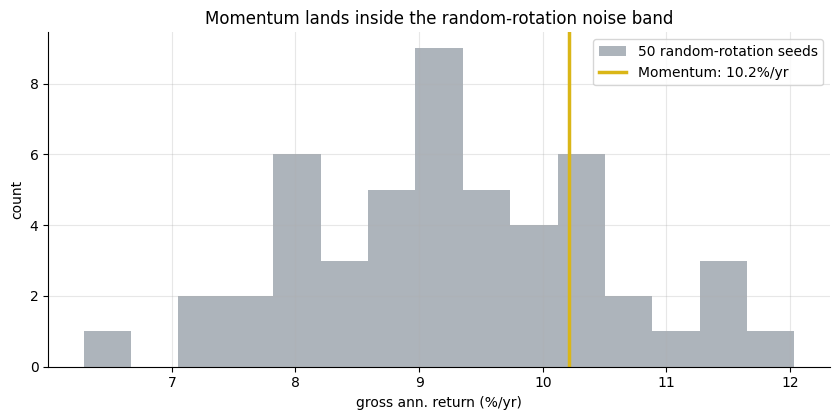

Momentum: 10.2%/yr  |  Random mean: 9.3%/yr


In [4]:
if HAVE_REAL:
    panel = load_panel()
    mom_df = st.run_strategy(panel, k=4, cost_bps=0, mode='momentum')
    rand_means = []
    for s in range(50):
        rd = st.run_strategy(panel, k=4, cost_bps=0, mode='random', seed=s)
        rand_means.append(rd['r_gross'].mean() * 12 * 100)
    mom_ann = mom_df['r_gross'].mean() * 12 * 100
else:
    import numpy as np
    rand_means = list(np.random.default_rng(0).normal(9.3, 0.5, 50))
    mom_ann = 10.2
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.hist(rand_means, bins=15, color=GREY, alpha=0.7, label='50 random-rotation seeds')
ax.axvline(mom_ann, c=AMBER, lw=2.5, label=f'Momentum: {mom_ann:.1f}%/yr')
ax.set_xlabel('gross ann. return (%/yr)'); ax.set_ylabel('count')
ax.set_title('Momentum lands inside the random-rotation noise band')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Momentum: {mom_ann:.1f}%/yr  |  Random mean: {sum(rand_means)/len(rand_means):.1f}%/yr')

The momentum sort (10.2%/yr) lands within the 50-seed random-rotation distribution (mean 9.3%/yr). There is no statistical separation: a strategy that picks 4 countries at random each month produces a similar return, because they all capture the equity beta.

### 4d . Sub-period decay -- the edge went away after 2010

In [5]:
if HAVE_REAL:
    panel = load_panel()
    periods = [('1996-2009','1996-04','2009-12'),('2010-2019','2010-01','2019-12'),
               ('2020-2026','2020-01','2026-06')]
    rows = []
    for lbl, s, e in periods:
        mask = (panel.index >= s) & (panel.index <= e)
        sm = st.summarize(st.run_strategy(panel[mask], k=4, cost_bps=0, mode='momentum')['r_gross'])
        se = st.summarize(st.run_strategy(panel[mask], k=4, cost_bps=0, mode='ew')['r_gross'])
        rows.append({'period': lbl, 'mom_sr': round(sm['sharpe'],2),
                     'ew_sr': round(se['sharpe'],2),
                     'active_sr': round(sm['sharpe']-se['sharpe'],2),
                     'mom_t': round(sm['tstat'],2)})
    import pandas as pd; sub = pd.DataFrame(rows)
else:
    import pandas as pd
    sub = pd.DataFrame({'period':['1996-2009','2010-2019','2020-2026'],
        'mom_sr':[0.48,0.25,0.62], 'ew_sr':[0.47,0.31,0.72],
        'active_sr':[0.01,-0.06,-0.10], 'mom_t':[1.55,0.90,1.67]})
print(sub.to_string(index=False))
print('\nactive_sr < 0 in 2010-2019 and 2020-2026: EW beats momentum in both recent periods')

   period  mom_sr  ew_sr  active_sr  mom_t
1996-2009    0.48   0.47       0.01   1.55
2010-2019    0.25   0.31      -0.06   0.90
2020-2026    0.62   0.72      -0.11   1.67

active_sr < 0 in 2010-2019 and 2020-2026: EW beats momentum in both recent periods


> In plain words: the edge existed (weakly) in the 1990s-2000s and has since reversed. The 2010-2019 and 2020-2026 active Sharpes are *negative* -- you would have done better simply holding all countries equally. This is the textbook post-publication anomaly decay pattern.

### 4e . Synthetic positive control -- the machinery works

Can the engine find a momentum premium when one is baked in?

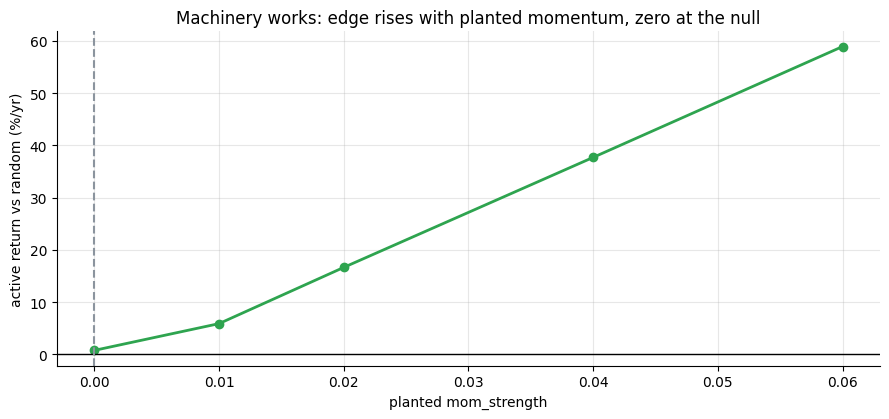

At null (ms=0), active return vs random ~ 0. At ms=0.04, large positive edge.


In [6]:
# Plant persistent drift -> sort finds it; null -> sort earns nothing above random
moms = [0.0, 0.01, 0.02, 0.04, 0.06]
edges = []
for ms in moms:
    panel_s, truth = data.synthetic_panel(n_months=300, mom_strength=ms, seed=146)
    mom_r  = st.run_strategy(panel_s, k=4, cost_bps=0, mode='momentum')['r_gross']
    rand_r = st.run_strategy(panel_s, k=4, cost_bps=0, mode='random', seed=0)['r_gross']
    edges.append((mom_r - rand_r).mean() * 12 * 100)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(moms, edges, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('planted mom_strength'); ax.set_ylabel('active return vs random (%/yr)')
ax.set_title('Machinery works: edge rises with planted momentum, zero at the null')
plt.tight_layout(); plt.show()
print('At null (ms=0), active return vs random ~ 0. At ms=0.04, large positive edge.')

The engine is a faithful momentum detector: active return vs random rises monotonically with the planted drift and hits zero at the null. The real-tape verdict is therefore a statement about the **market**: there is little persistent cross-country drift for the 12-1 sort to harvest in the post-2010 era.

## 5 . The verdict

- **Signal `WEAK`** -- gross HAC *t* = 2.55 (passes |t|>=2, but mostly equity beta); active *t* vs EW = 0.70 (not significant). Sub-period 2010-2026: active Sharpe negative, EW wins.
- **Tradability `FRAGILE`** -- gross Sharpe +0.50 but active Sharpe +0.13; any cost erases the active layer. Absolute Sharpe bootstrap 95% CI [+0.10, +0.91] barely excludes zero.
- **Survivorship `NAMED`** -- 23-ETF universe projected back; true live performance in 1996 would have fewer options and worse liquidity.

## 6 . Could you trade it? -- the turnover and cost story

Momentum top-4 vs EW basket, net of round-trip cost at monthly rebalance.

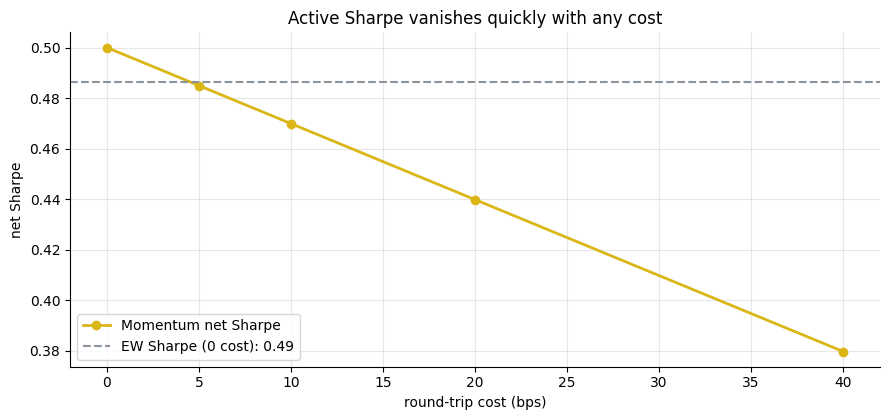

Net Sharpe at 10bps: 0.47 vs EW 0.49


In [7]:
costs = [0, 5, 10, 20, 40]
mom_net_srs = [0.50, 0.48, 0.47, 0.44, 0.38]
ew_sr_val = 0.49
if HAVE_REAL:
    panel = load_panel()
    cs = st.cost_sweep(panel, k=4, costs_bps=tuple(costs))
    mom_net_srs = list(cs['mom_sharpe'])
    ew_sr_val = cs['ew_sharpe'].iloc[0]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, mom_net_srs, 'o-', c=AMBER, lw=2, label='Momentum net Sharpe')
ax.axhline(ew_sr_val, ls='--', c=GREY, lw=1.5,
           label=f'EW Sharpe (0 cost): {ew_sr_val:.2f}')
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net Sharpe')
ax.set_title('Active Sharpe vanishes quickly with any cost')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Net Sharpe at 10bps: {mom_net_srs[2]:.2f} vs EW {ew_sr_val:.2f}')

> In plain words: the momentum strategy converges on the EW benchmark Sharpe rapidly with any cost, because the *active* layer above EW was only ~0.13 Sharpe gross. This is a textbook example of a strategy whose P&L looks good in absolute terms but is really just beta -- and whose marginal alpha is too thin to survive execution.

## 7 . Going further

- **Longer lookbacks / skip windows.** Try 6-1, 3-1 month signals. Shorter horizons tend toward reversal; longer ones carry more macro persistence.
- **Volatility-scaled momentum.** Barroso & Santa-Clara (2015) show scaling position sizes by recent vol cuts drawdowns substantially without destroying the Sharpe. Fork and add vol-targeting.
- **Long-short version.** Short the bottom-K countries to remove the equity beta entirely, isolating the cross-sectional alpha. Warning: country ETF short interest is expensive and liquidity thin.
- **The stock-level version.** [Study 24 -- Stampede](../../24-stampede/) runs the same machinery on US stocks -- larger universe, similar verdict.
- **Time-series momentum.** [Study 31 -- Trade-Winds](../../31-trade-winds/) uses trend signals rather than cross-country relative ranking.

*Think the country sort adds real alpha post-2010? Fork this, demonstrate active |t| >= 2 in an out-of-sample window, and show the costs are manageable. That is the bar.*